In [1]:
%load_ext autoreload
%autoreload 2

# Import libraries

In [2]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl


import mujoco


# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags



Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl


In [3]:
# @title Import packages for plotting and creating graphics
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

# Load env and simple rollout

In [4]:
from mujoco_playground import registry

env_name = 'RobcoArm'

env = env = registry.load(env_name)
print(env.observation_size)
print(env.action_size)
env_cfg = registry.get_default_config(env_name)
env_cfg

W1123 15:21:27.600388 3233494 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
W1123 15:21:27.610071 3233013 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
/home/ngt/.conda/envs/playground/lib/python3.11/site-packages/jax/_src/abstract_arrays.py:135: RuntimeWarning: overflow encountered in cast
  return literals.TypedNdArray(np.asarray(x, dtype), weak_type=False)


18
6


action_repeat: 1
action_scale: 4.7124
ctrl_dt: 0.02
episode_length: 500
impl: jax
nconmax: 32
njmax: 8
reward_config:
  scales:
    end_effector_target: 8.0
    energy: 1
    ground_collision: 1
    self_collision: 1
sim_dt: 0.002
success_distance_threshold: 0.05
vision: false

In [5]:
from mujoco_playground.config import robco_params
ppo_params = robco_params.get_default_config(env_name)
ppo_params

action_repeat: 1
action_scale: 4.7124
ctrl_dt: 0.02
episode_length: 500
impl: jax
nconmax: 32
njmax: 8
reward_config:
  scales:
    end_effector_target: 8.0
    energy: 1
    ground_collision: 1
    self_collision: 1
sim_dt: 0.002
success_distance_threshold: 0.05
vision: false

In [6]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [7]:
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state]

f = 0.5
for i in range(env_cfg.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.array(action)
  state = jit_step(state, action)
  rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 501/501 [00:01<00:00, 381.54it/s]


This browser does not support the video tag.


# Brax PPO

In [8]:
from mujoco_playground.config import robco_params
ppo_params = robco_params.robco_ppo_config(env_name)
ppo_params["num_timesteps"] = 10_000

In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  print(num_steps)
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([-5000, 0])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
  

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

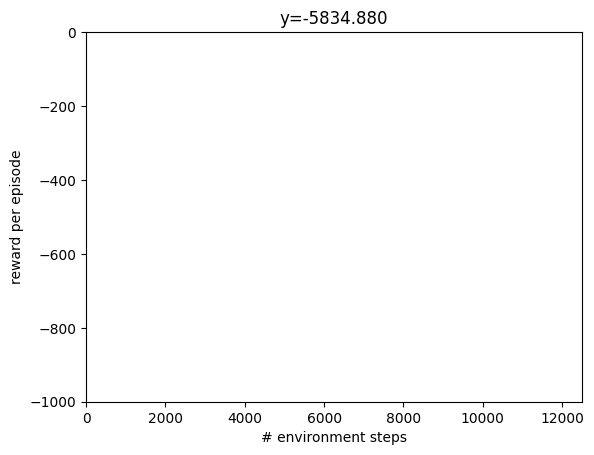

In [ ]:
from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

# Visualize Rollout

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)